In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
from functions import dL_rosenbrock_1d
from src.optimizer import AdamScratch1D, NonlocalSolverMomentumAdam
from src.utils import AdamPlotter
import matplotlib.pyplot as plt
import numpy as np

# CONDITIONS

In [3]:
a = 1
lr = 0.001
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
epochs = int(1e4)
initial_theta = 5.0

# DISCRETE-ADAM

In [4]:

optimizer = AdamScratch1D(
    dL = dL_rosenbrock_1d,
    lr=lr,
    beta1=beta1,
    beta2=beta2,
    epsilon=epsilon,
    epochs=epochs
)

theta_history, m_history, v_history, iterations = optimizer.solve(
    theta_initial=initial_theta,
    function_parameters=(a,)
    )

print(f"Valor final de theta: {theta_history[-1]}")


Epoch: 50, theta=4.950184e+00, Error: 9.904697e-04
Epoch: 100, theta=4.901034e+00, Error: 9.757909e-04
Epoch: 150, theta=4.852614e+00, Error: 9.613651e-04
Epoch: 200, theta=4.804905e+00, Error: 9.473321e-04
Epoch: 250, theta=4.757888e+00, Error: 9.336783e-04
Epoch: 300, theta=4.711545e+00, Error: 9.203896e-04
Epoch: 350, theta=4.665857e+00, Error: 9.074529e-04
Epoch: 400, theta=4.620807e+00, Error: 8.948554e-04
Epoch: 450, theta=4.576378e+00, Error: 8.825850e-04
Epoch: 500, theta=4.532555e+00, Error: 8.706300e-04
Epoch: 550, theta=4.489322e+00, Error: 8.589792e-04
Epoch: 600, theta=4.446664e+00, Error: 8.476221e-04
Epoch: 650, theta=4.404566e+00, Error: 8.365482e-04
Epoch: 700, theta=4.363015e+00, Error: 8.257477e-04
Epoch: 750, theta=4.321998e+00, Error: 8.152110e-04
Epoch: 800, theta=4.281500e+00, Error: 8.049292e-04
Epoch: 850, theta=4.241511e+00, Error: 7.948933e-04
Epoch: 900, theta=4.202017e+00, Error: 7.850951e-04
Epoch: 950, theta=4.163007e+00, Error: 7.755262e-04
Epoch: 1000, 

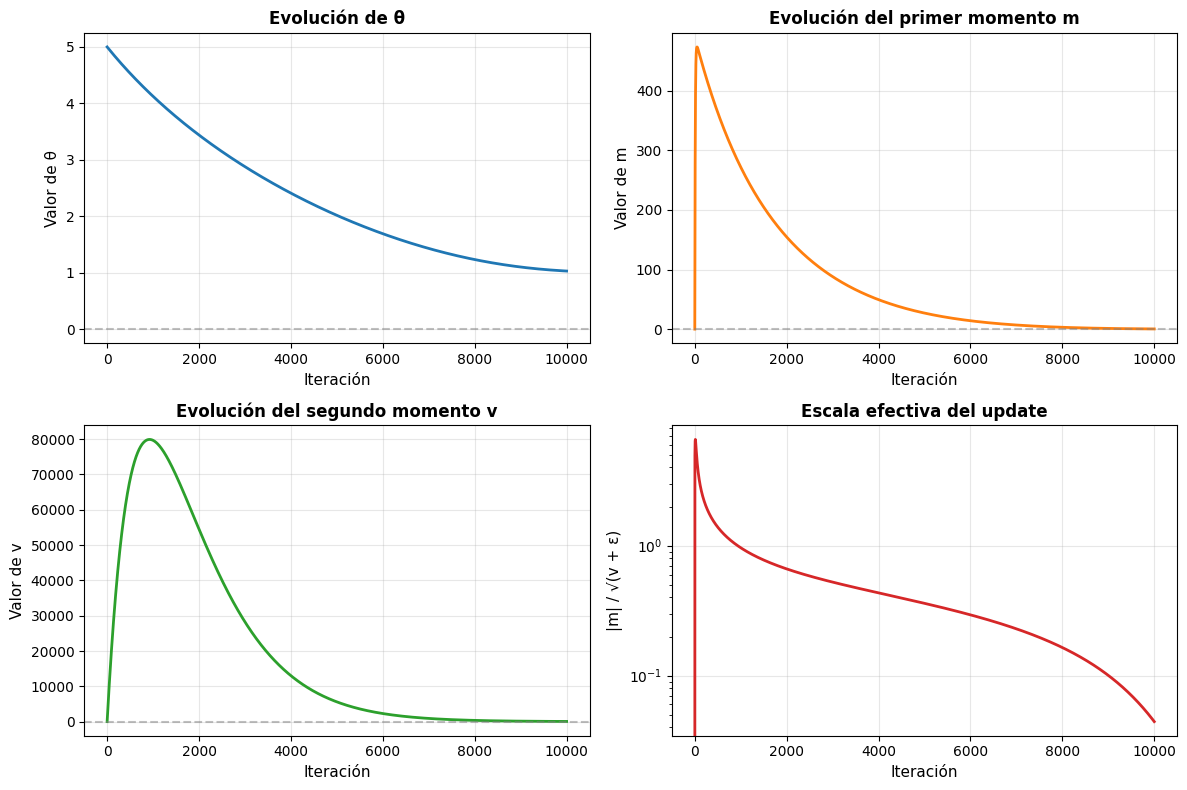

In [5]:
# Crear el plotter y visualizar
plotter = AdamPlotter(theta_history, m_history, v_history)

# Plotear todo
plotter.plot('all')
plt.show()

# CONTINUOUS ADAM

In [6]:
def dL_wrapper(theta):
    return dL_rosenbrock_1d(theta, (a,))

In [8]:
print("Resolviendo theta1...")
optimizer_theta = NonlocalSolverMomentumAdam(
    dL=dL_wrapper,
    t_span=(lr, 10.0),
    y0=[initial_theta, 0.0],
    alpha=lr,
    betas=(beta1, beta2),
    eps_base=epsilon,
    verbose=True,
    quad_order=50
)
t, y = optimizer_theta.solve()

theta_history = y[:, 0]
theta_dot_history = y[:, 1]
final_state = theta_history[-1]
if isinstance(final_state, np.ndarray) and final_state.size > 1:
    # Ecuación de 2do orden
    print(f"\nValor final de theta: {final_state[0]:.6e}")
    print(f"Velocidad final: {final_state[1]:.6e}")
else:
    # Ecuación de 1er orden (escalar)
    print(f"\nValor final de theta: {float(final_state):.6e}")

print(f"Tiempo final: {t[-1]}")
print(f"Número de pasos: {len(t)}")

Resolviendo theta1...
Second order equation --> using sinh/sin kernels
ParallelComputation: joblib backend='loky', workers=23/24

Building functional RHS (iteration 0)...
¿No finitos en y?: False (NaN: False, Inf: False)

--- DEBUG interpolador ---
y_pos shape: (9999,), dtype: float64
y_pos[:5]: [5. 5. 5. 5. 5.]
y_pos finitos: True
--- FIN DEBUG ---

Computing moments for 9999 time points...
  Parallel execution: 9999 items → 23 workers (joblib/loky)
Moments computed in 2.20s
m[0]=0.000e+00, v[0]=0.000e+00
m[1]=2.731e+01, v[1]=1.352e+02
m[-1]=5.164e+02, v[-1]=2.383e+05
Iter 0 – err 608.6270129216477

Building functional RHS (iteration 1)...
¿No finitos en y?: False (NaN: False, Inf: False)

--- DEBUG interpolador ---
y_pos shape: (9999,), dtype: float64
y_pos[:5]: [5.         5.         4.99944723 4.99925156 4.99860662]
y_pos finitos: True
--- FIN DEBUG ---

Computing moments for 9999 time points...
  Parallel execution: 9999 items → 23 workers (joblib/loky)
Moments computed in 1.60s
m

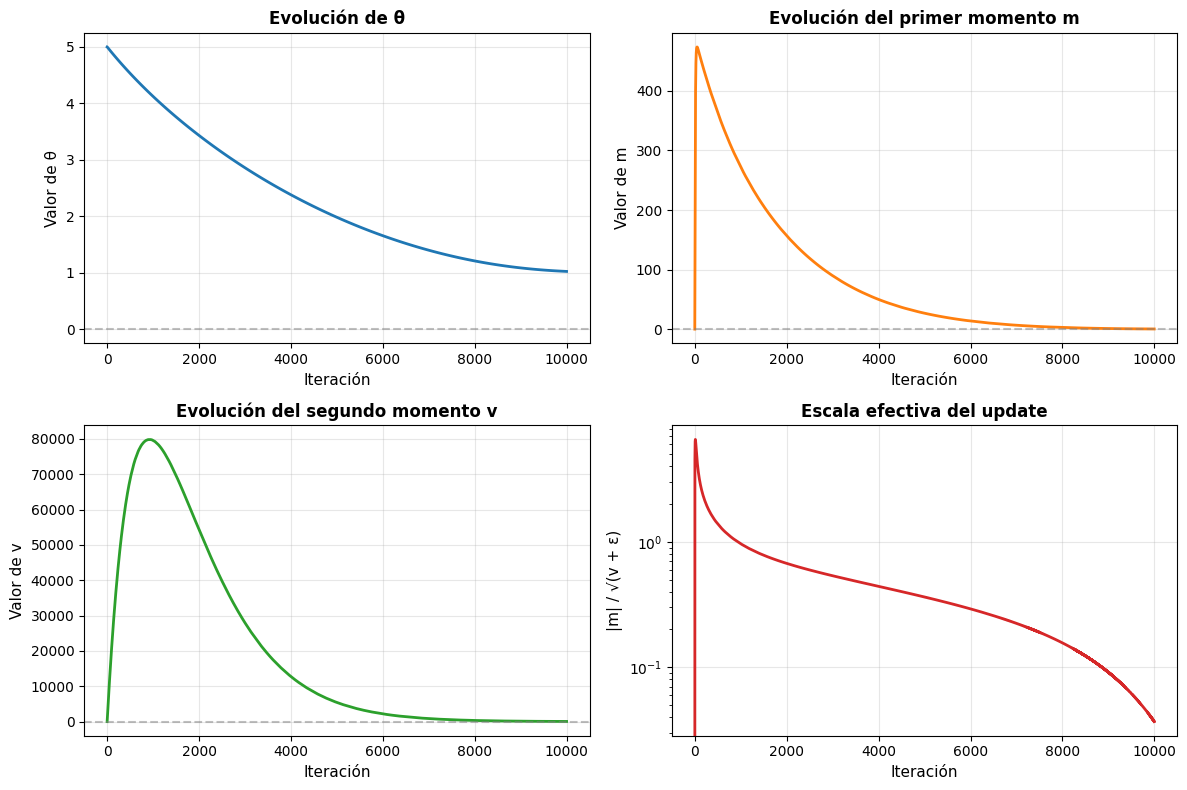

In [9]:
# Crear el plotter y visualizar
plotter = AdamPlotter(theta_history, optimizer_theta._last_m[:, 1], optimizer_theta._last_v[:, 1])

# Plotear todo
plotter.plot('all')
plt.show()